# Exercise 4: Chemostat Analysis (Yeast Biomass Production)

Steady-state chemostat data for yeast growth:
- Feed substrate concentration: $S_0 = 10$ g/L
- Excess oxygen provided

### Key equations (Monod kinetics with maintenance)

**Monod growth rate:**
$$\mu = \frac{\mu_{max} \cdot S}{K_s + S}$$

**At steady state in chemostat:** $\mu = D$

$$S = \frac{D \cdot K_s}{\mu_{max} - D}$$

**Substrate balance (with maintenance):**
$$r_s = \frac{r_X}{Y_{X/S}} + m \cdot X$$

At steady state: $D(S_0 - S) = r_s = \frac{\mu X}{Y_{X/S}} + m \cdot X = \frac{D \cdot X}{Y_{X/S}} + m \cdot X$

$$X = \frac{Y_{X/S}(S_0 - S)}{1 + m \cdot Y_{X/S}/D}$$

**Productivity:** $P = D \cdot X$

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [39]:
#Experimental data:
D_data = np.array([0.05, 0.10, 0.20, 0.40, 0.60, 0.70, 0.80, 0.84])  # h⁻¹
X_data = np.array([3.20, 3.70, 4.00, 4.40, 4.75, 4.90, 4.50, 0.50])  # g/L
S_data = np.array([0.012, 0.028, 0.050, 0.100, 0.150, 0.176, 0.800, 9.000])  # g/L

S0 = 10.0  # g/L  feed substrate

# Separate washout point (D=0.84) from steady operating data
# Use only points clearly before washout for parameter fitting
mask = D_data <= 0.70
D_fit = D_data[mask]
X_fit = X_data[mask]
S_fit = S_data[mask]

print("Experimental Data:")
print(f"{'D (h⁻¹)':>10} {'X (g/L)':>10} {'S (g/L)':>10}")
for d, x, s in zip(D_data, X_data, S_data):
    print(f"{d:10.3f} {x:10.3f} {s:10.3f}")

Experimental Data:
   D (h⁻¹)    X (g/L)    S (g/L)
     0.050      3.200      0.012
     0.100      3.700      0.028
     0.200      4.000      0.050
     0.400      4.400      0.100
     0.600      4.750      0.150
     0.700      4.900      0.176
     0.800      4.500      0.800
     0.840      0.500      9.000


### Part (a): Estimate $\mu_{max}$ and $K_s$ (Monod kinetics)

At steady state $\mu = D$, so we fit the Monod equation directly:
$$D = \frac{\mu_{max} \cdot S}{K_s + S}$$

Equivalently (Lineweaver–Burk linearisation):
$$\frac{1}{D} = \frac{K_s}{\mu_{max}} \cdot \frac{1}{S} + \frac{1}{\mu_{max}}$$

Monod fit results:
  μ_max = 70841.7902 h⁻¹
  K_s   = 17777.7924 g/L

Lineweaver–Burk linearisation:
  μ_max = 3.7175 h⁻¹
  K_s   = 0.8979 g/L


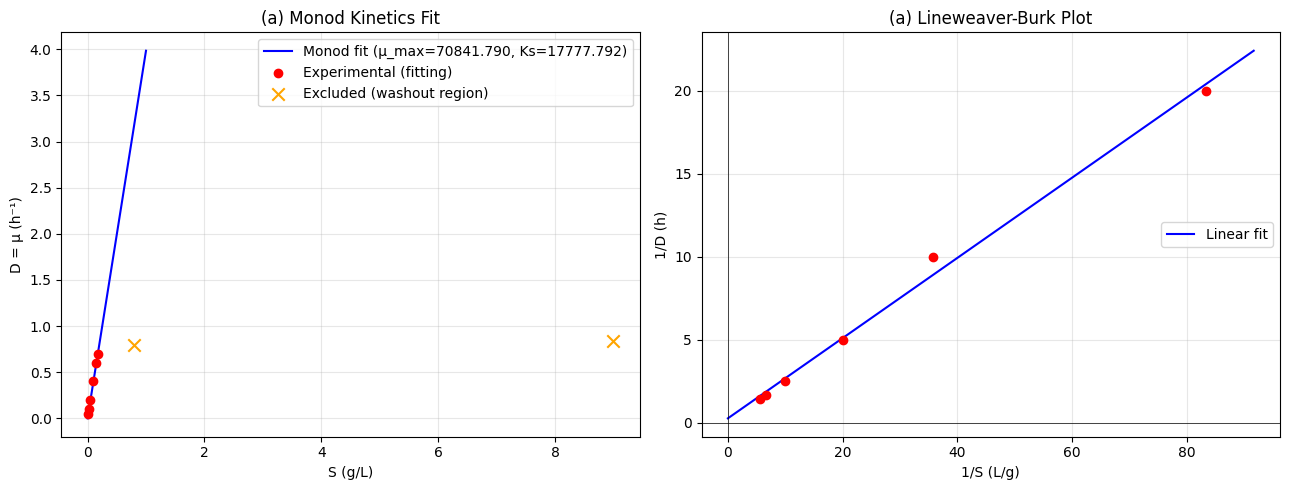


Using nonlinear fit values for all subsequent calculations.


In [47]:
#(a) Fit Monod parameters using nonlinear least squares:
def monod(S, mu_max, Ks):
    return mu_max * S / (Ks + S)

popt, pcov = curve_fit(monod, S_fit, D_fit, p0=[1.0, 0.1], bounds=(0, np.inf))
mu_max, Ks = popt
print(f"Monod fit results:")
print(f"  μ_max = {mu_max:.4f} h⁻¹")
print(f"  K_s   = {Ks:.4f} g/L")

# Lineweaver–Burk plot (for visualisation)
inv_D = 1.0 / D_fit
inv_S = 1.0 / S_fit
lb_coeffs = np.polyfit(inv_S, inv_D, 1)  # slope = Ks/mu_max, intercept = 1/mu_max
mu_max_lb = 1.0 / lb_coeffs[1]
Ks_lb = lb_coeffs[0] * mu_max_lb
print(f"\nLineweaver–Burk linearisation:")
print(f"  μ_max = {mu_max_lb:.4f} h⁻¹")
print(f"  K_s   = {Ks_lb:.4f} g/L")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Monod curve
S_range = np.linspace(0, 1.0, 300)
axes[0].plot(S_range, monod(S_range, mu_max, Ks), 'b-', label=f'Monod fit (μ_max={mu_max:.3f}, Ks={Ks:.3f})')
axes[0].scatter(S_fit, D_fit, color='red', zorder=5, label='Experimental (fitting)')
axes[0].scatter(S_data[~mask], D_data[~mask], color='orange', marker='x', s=80, zorder=5, label='Excluded (washout region)')
axes[0].set_xlabel('S (g/L)')
axes[0].set_ylabel('D = μ (h⁻¹)')
axes[0].set_title('(a) Monod Kinetics Fit')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Lineweaver–Burk
x_lb = np.linspace(0, max(inv_S)*1.1, 200)
axes[1].plot(x_lb, np.polyval(lb_coeffs, x_lb), 'b-', label='Linear fit')
axes[1].scatter(inv_S, inv_D, color='red', zorder=5)
axes[1].axhline(0, color='k', linewidth=0.5)
axes[1].axvline(0, color='k', linewidth=0.5)
axes[1].set_xlabel('1/S (L/g)')
axes[1].set_ylabel('1/D (h)')
axes[1].set_title('(a) Lineweaver-Burk Plot')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(r'C:\Users\noah2\OneDrive\Documents\GitHub\Projects\Bioreactor-mod-simulation\Project_2\Images\ex4_part_A.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nUsing nonlinear fit values for all subsequent calculations.")

### Part (b): Estimate $Y_{X/S}$ and maintenance coefficient $m$

From the substrate balance at steady state:
$$D(S_0 - S) = \frac{D \cdot X}{Y_{X/S}} + m \cdot X$$

Rearranging:
$$\frac{D(S_0 - S)}{X} = \frac{D}{Y_{X/S}} + m$$

This is linear in $D$: plot $\frac{D(S_0-S)}{X}$ vs $D$, slope $= 1/Y_{X/S}$, intercept $= m$.

Yield and maintenance estimates:
  Y_X/S = 0.5205 g_X/g_S
  m     = 0.0887 g_S/(g_X·h)


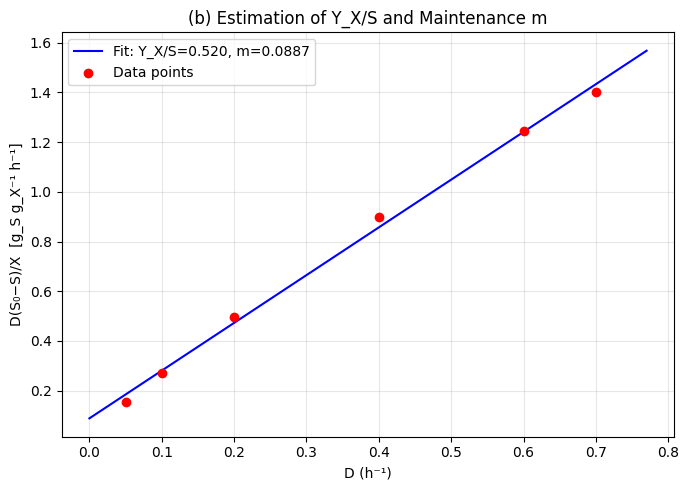

In [41]:
#(b) Yield and maintenance:
q_s = D_fit * (S0 - S_fit) / X_fit   # specific substrate uptake rate [g_S / g_X / h]

# Linear regression: q_s = D / Y_XS + m
coeffs_b = np.polyfit(D_fit, q_s, 1)
Y_XS = 1.0 / coeffs_b[0]
m_maint = coeffs_b[1]

print(f"Yield and maintenance estimates:")
print(f"  Y_X/S = {Y_XS:.4f} g_X/g_S")
print(f"  m     = {m_maint:.4f} g_S/(g_X·h)")

fig, ax = plt.subplots(figsize=(7, 5))
D_line = np.linspace(0, max(D_fit)*1.1, 200)
ax.plot(D_line, np.polyval(coeffs_b, D_line), 'b-', label=f'Fit: Y_X/S={Y_XS:.3f}, m={m_maint:.4f}')
ax.scatter(D_fit, q_s, color='red', zorder=5, label='Data points')
ax.set_xlabel('D (h⁻¹)')
ax.set_ylabel('D(S₀−S)/X  [g_S g_X⁻¹ h⁻¹]')
ax.set_title('(b) Estimation of Y_X/S and Maintenance m')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(r'C:\Users\noah2\OneDrive\Documents\GitHub\Projects\Bioreactor-mod-simulation\Project_2\Images\ex4_part_B.png', dpi=150, bbox_inches='tight')
plt.show()

### Part (c): $D_{max}$ and $D_{opt}$ (ignoring maintenance)

##### Derivation of $D_{max}$

At steady state the Monod equation equals the dilution rate:
$$\mu = D = \frac{\mu_{max} S}{K_s + S}$$

Solving for the steady-state substrate concentration $S$:
$$D(K_s + S) = \mu_{max} S$$
$$D K_s = (\mu_{max} - D)\, S$$
$$\boxed{S(D) = \frac{D\, K_s}{\mu_{max} - D}}$$

As $D$ increases, $S$ increases. Washout occurs when the reactor substrate concentration reaches the feed concentration, i.e. $S \to S_0$ (no substrate is consumed because there is no biomass left). Setting $S = S_0$:
$$S_0 = \frac{D_{max}\, K_s}{\mu_{max} - D_{max}}$$
$$S_0(\mu_{max} - D_{max}) = D_{max}\, K_s$$
$$S_0\,\mu_{max} = D_{max}(K_s + S_0)$$
$$\boxed{D_{max} = \frac{\mu_{max}\, S_0}{K_s + S_0}}$$

##### Derivation of $D_{opt}$ (maximum biomass productivity)

**Step 1: Write $X$ as a function of $D$ (no maintenance, $m=0$).**

The steady-state substrate balance simplifies to:
$$D(S_0 - S) = \frac{D\,X}{Y_{X/S}} \implies X = Y_{X/S}(S_0 - S)$$

Substituting $S(D)$ from above:
$$X(D) = Y_{X/S}\left(S_0 - \frac{D\,K_s}{\mu_{max}-D}\right) = Y_{X/S}\cdot\frac{S_0(\mu_{max}-D) - D\,K_s}{\mu_{max}-D}$$
$$\boxed{X(D) = Y_{X/S}\cdot\frac{\mu_{max}S_0 - D(K_s+S_0)}{\mu_{max}-D}}$$

**Step 2: Form the productivity $P = D \cdot X$.**

Let $A = \mu_{max}S_0$ and $B = K_s + S_0$ for brevity:
$$P(D) = D \cdot X(D) = Y_{X/S}\cdot\frac{D(A - B\,D)}{\mu_{max}-D}$$

**Step 3: Differentiate $P$ with respect to $D$ and set to zero.**

Using the quotient rule on $f(D) = \dfrac{D(A-BD)}{\mu_{max}-D}$:

Numerator of $f$: $u = D(A-BD) = AD - BD^2$, so $u' = A - 2BD$  
Denominator: $v = \mu_{max}-D$, so $v' = -1$

$$f'(D) = \frac{u'v - uv'}{v^2} = \frac{(A-2BD)(\mu_{max}-D) + D(A-BD)}{(\mu_{max}-D)^2}$$

Setting $f'(D)=0$ means the numerator must vanish:
$$(A-2BD)(\mu_{max}-D) + D(A-BD) = 0$$

Expanding:
$$A\mu_{max} - AD - 2BD\mu_{max} + 2BD^2 + AD - BD^2 = 0$$
$$A\mu_{max} - 2BD\mu_{max} + BD^2 = 0$$

Dividing by $B$:
$$D^2 - 2\mu_{max}D + \frac{A}{B}\mu_{max} = 0$$

Recall $A/B = \mu_{max}S_0/(K_s+S_0)$, so:
$$D^2 - 2\mu_{max}D + \frac{\mu_{max}^2 S_0}{K_s+S_0} = 0$$

**Step 4: Solve the quadratic.**

$$D = \frac{2\mu_{max} \pm \sqrt{4\mu_{max}^2 - 4\,\dfrac{\mu_{max}^2 S_0}{K_s+S_0}}}{2} = \mu_{max}\left(1 \pm \sqrt{1 - \frac{S_0}{K_s+S_0}}\right)$$

$$= \mu_{max}\left(1 \pm \sqrt{\frac{K_s}{K_s+S_0}}\right)$$

The ($+$) root exceeds $D_{max}$ (non-physical), so we take the ($-$) root:

$$\boxed{D_{opt} = \mu_{max}\left(1 - \sqrt{\frac{K_s}{K_s+S_0}}\right)}$$

In [42]:
#(c) D_max and D_opt (no maintenance):
D_max = mu_max * S0 / (Ks + S0)
D_opt = mu_max * (1 - np.sqrt(Ks / (Ks + S0)))

print(f"D_max (washout) = {D_max:.4f} h⁻¹")
print(f"D_opt (max productivity, no maintenance) = {D_opt:.4f} h⁻¹")

D_max (washout) = 39.8261 h⁻¹
D_opt (max productivity, no maintenance) = 19.9158 h⁻¹


### Part (d): X and S as functions of D (with maintenance)

At steady state, combining the Monod equation with the substrate balance:

$$S(D) = \frac{D \cdot K_s}{\mu_{max} - D}$$

$$X(D) = \frac{Y_{X/S}(S_0 - S)}{1 + m \cdot Y_{X/S}/D}$$

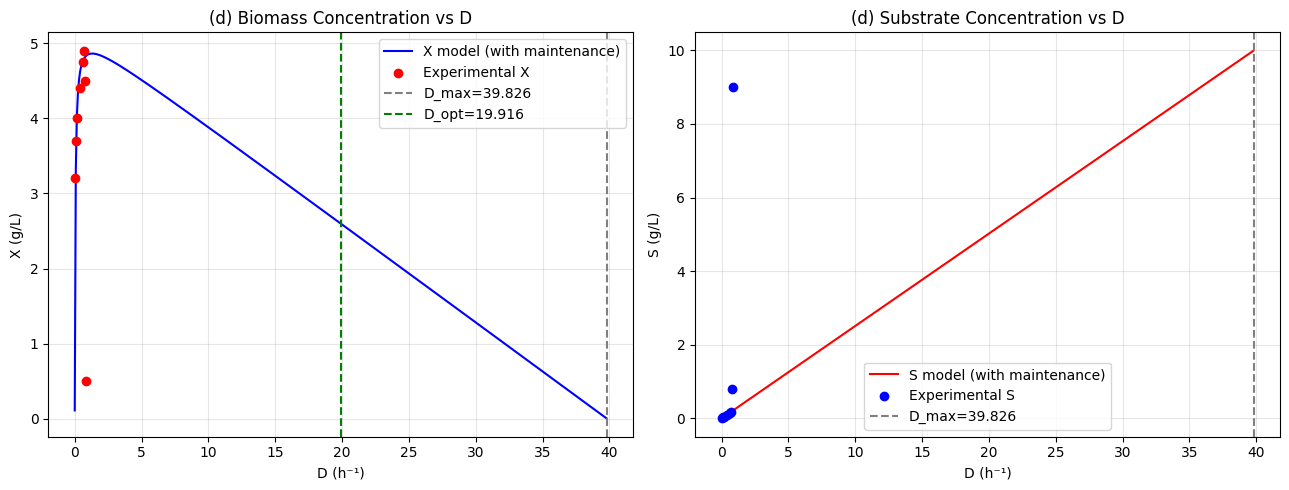

In [43]:
#(d) X(D) and S(D) with maintenance:
D_range = np.linspace(0.001, D_max * 0.999, 500)

def steady_state(D, mu_max, Ks, Y_XS, m, S0):
    S_ss = D * Ks / (mu_max - D)
    S_ss = np.clip(S_ss, 0, S0)
    denom = 1 + m * Y_XS / D
    X_ss = Y_XS * (S0 - S_ss) / denom
    X_ss = np.maximum(X_ss, 0)
    return S_ss, X_ss

S_model, X_model = steady_state(D_range, mu_max, Ks, Y_XS, m_maint, S0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(D_range, X_model, 'b-', label='X model (with maintenance)')
axes[0].scatter(D_data, X_data, color='red', zorder=5, label='Experimental X')
axes[0].axvline(D_max, color='gray', linestyle='--', label=f'D_max={D_max:.3f}')
axes[0].axvline(D_opt, color='green', linestyle='--', label=f'D_opt={D_opt:.3f}')
axes[0].set_xlabel('D (h⁻¹)')
axes[0].set_ylabel('X (g/L)')
axes[0].set_title('(d) Biomass Concentration vs D')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(D_range, S_model, 'r-', label='S model (with maintenance)')
axes[1].scatter(D_data, S_data, color='blue', zorder=5, label='Experimental S')
axes[1].axvline(D_max, color='gray', linestyle='--', label=f'D_max={D_max:.3f}')
axes[1].set_xlabel('D (h⁻¹)')
axes[1].set_ylabel('S (g/L)')
axes[1].set_title('(d) Substrate Concentration vs D')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(r'C:\Users\noah2\OneDrive\Documents\GitHub\Projects\Bioreactor-mod-simulation\Project_2\Images\ex4_part_D.png', dpi=150, bbox_inches='tight')
plt.show()

### Part (e): Productivity $D \cdot X$ vs D; effect of $K_s$

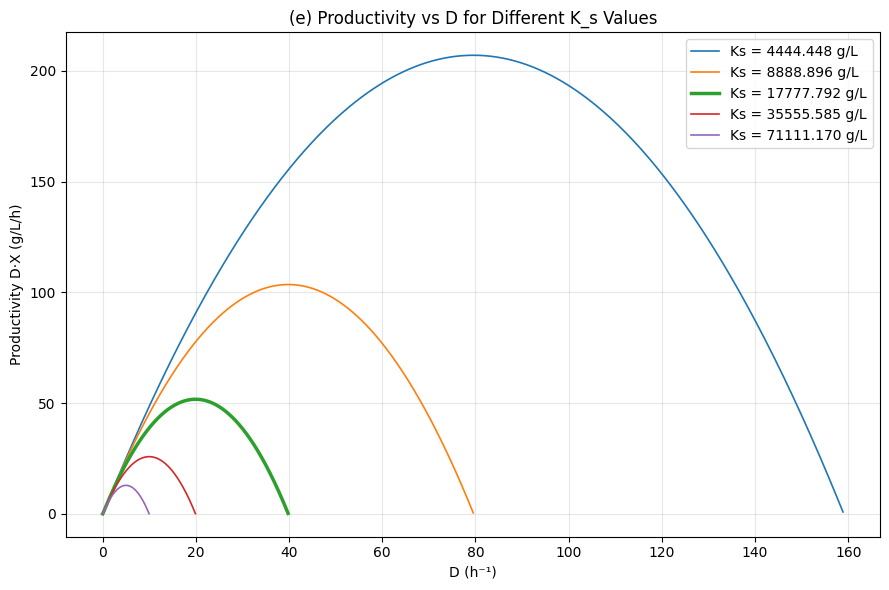

Observation: Increasing Ks lowers the maximum achievable productivity
and shifts the optimal dilution rate to lower values.


In [44]:
# ── (e) Productivity vs D for different Ks values ────────────────────────────
Ks_values = [Ks * 0.25, Ks * 0.5, Ks, Ks * 2, Ks * 4]
labels = [f'Ks = {k:.3f} g/L' for k in Ks_values]

fig, ax = plt.subplots(figsize=(9, 6))

for Ks_i, lbl in zip(Ks_values, labels):
    D_max_i = mu_max * S0 / (Ks_i + S0)
    D_r = np.linspace(0.001, D_max_i * 0.999, 500)
    S_i, X_i = steady_state(D_r, mu_max, Ks_i, Y_XS, m_maint, S0)
    productivity_i = D_r * X_i
    lw = 2.5 if abs(Ks_i - Ks) < 1e-9 else 1.2
    ax.plot(D_r, productivity_i, linewidth=lw, label=lbl)

ax.set_xlabel('D (h⁻¹)')
ax.set_ylabel('Productivity D·X (g/L/h)')
ax.set_title('(e) Productivity vs D for Different K_s Values')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(r'C:\Users\noah2\OneDrive\Documents\GitHub\Projects\Bioreactor-mod-simulation\Project_2\Images\ex4_part_E.png', dpi=150, bbox_inches='tight')
plt.show()

print("Observation: Increasing Ks lowers the maximum achievable productivity")
print("and shifts the optimal dilution rate to lower values.")

### Part (f): Maximum productivity and corresponding $D$ (with the $K_s$ from part a)

Maximum productivity (with maintenance):
  D_opt  = 19.9335 h⁻¹
  P_max  = 51.7154 g/(L·h)
  X at D_opt = 2.5944 g/L


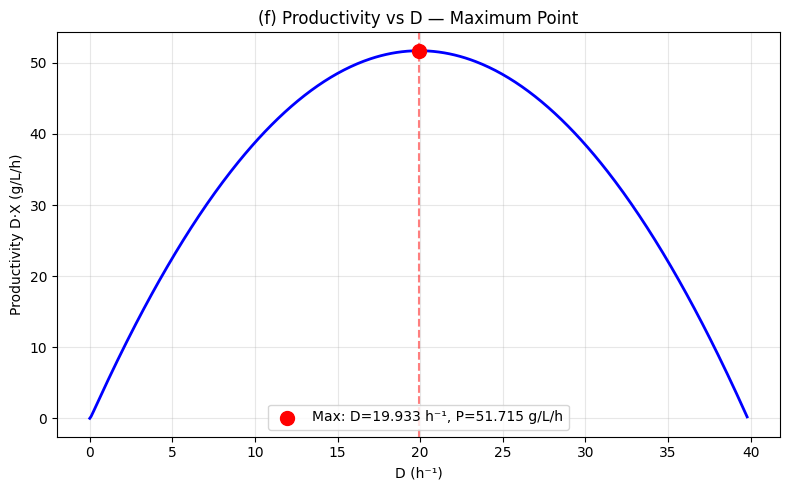

In [45]:
#(f) Maximum productivity:
S_model_f, X_model_f = steady_state(D_range, mu_max, Ks, Y_XS, m_maint, S0)
productivity = D_range * X_model_f

idx_max = np.argmax(productivity)
D_opt_f = D_range[idx_max]
P_max   = productivity[idx_max]
X_at_Dopt = X_model_f[idx_max]

print(f"Maximum productivity (with maintenance):")
print(f"  D_opt  = {D_opt_f:.4f} h⁻¹")
print(f"  P_max  = {P_max:.4f} g/(L·h)")
print(f"  X at D_opt = {X_at_Dopt:.4f} g/L")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(D_range, productivity, 'b-', linewidth=2)
ax.scatter([D_opt_f], [P_max], color='red', s=100, zorder=5,
           label=f'Max: D={D_opt_f:.3f} h⁻¹, P={P_max:.3f} g/L/h')
ax.axvline(D_opt_f, color='red', linestyle='--', alpha=0.5)
ax.set_xlabel('D (h⁻¹)')
ax.set_ylabel('Productivity D·X (g/L/h)')
ax.set_title('(f) Productivity vs D — Maximum Point')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(r'C:\Users\noah2\OneDrive\Documents\GitHub\Projects\Bioreactor-mod-simulation\Project_2\Images\ex4_part_F.png', dpi=150, bbox_inches='tight')
plt.show()

## Part (g): Compare $D_{opt}$ from (c) and (f)

#### Comparison of $D_{opt}$ values: 
- $D_{opt}$ from (c): analytical, no maintenance = 19.9158 $h^{-1}$
- $D_{opt}$ from (f): numerical, with maintenance = 19.9335 $h^{-1}$

#### Interpretation:
  Including maintenance energy shifts the optimal dilution rate slightly
  downward because maintenance consumes substrate that would otherwise
  support growth. At lower D, cells have more time to utilise substrate
  for growth relative to maintenance losses.
#### Summary of estimated parameters:

- $\mu_{max} = 70841.7902$ $h^{-1}$
- $K_s = 17777.7924$ $g/L$
- $Y_{X/S} = 0.5205$ $g_X/g_S$
- $m = 0.08866$ $g_S/g_X*h$
- $D_{max} = 39.8261$ $h^{-1}$
- $D_{opt} (\text{no maint.}) = 19.9158$ $h^{-1}$
- $D_{opt} (\text{with maint.}) = 19.9335$ $h^{-1}$
- $P_{max} = 51.7154$ $g/L*h$